In [25]:
using JLD2
using DataFrames
using CSV
using Plots
using CairoMakie
using Statistics
using HiddenMarkovModels
using DriftDiffusionModels
using Distributions
using BSON: @load
using Dates
using Printf
using Random
using Distributions
using FFTW
using LinearAlgebra

In [5]:
# glmhmm posteriors 
post_file = load("/Users/senne/Downloads/best_gammas2.jld2")
gammas_dict = sort(post_file["gammas_dict"])

# read in params for each model fit
glmhmm_params = CSV.read("/Users/senne/Downloads/FINAL_fit3.csv", DataFrame)

# get needed variables for confusion matrix analysis
unique_animals = sort(unique([split_string[1] for split_string in [split(rat_str, "_") for rat_str in glmhmm_params.rat]]))
best_run = [parse(Int, split(String(k), "_")[2][4:end]) for k in keys(gammas_dict)];



In [42]:
best_run

18-element Vector{Int64}:
  4
 10
  4
  8
  4
  8
  5
  4
 10
  8
  2
  6
  8
  5
  6
  4
  1
  2

In [40]:
gammas_dict

OrderedCollections.OrderedDict{String, Matrix{Float64}} with 18 entries:
  "1029_run4"   => [0.0118465 0.0112703 … 0.254817 0.248366; 0.907179 0.908888 …
  "1052_run10"  => [0.0205715 0.0186696 … 0.747991 0.743474; 0.217595 0.366793 …
  "1054_run4"   => [0.0153371 0.0147474 … 0.947841 0.924089; 0.630283 0.625163 …
  "1059_run8"   => [0.577962 0.0840425 … 0.548685 0.544763; 0.0253707 0.0256194…
  "1060_run4"   => [0.490355 0.355638 … 5.24192e-5 8.3996e-5; 0.00911072 0.0045…
  "1062_run8"   => [0.00125425 0.0004622 … 0.0311586 0.031361; 0.951275 0.96436…
  "1064_run5"   => [0.00328364 0.0271996 … 0.442735 0.235405; 0.875236 0.897772…
  "1065_run4"   => [0.695618 0.863032 … 0.748469 0.162276; 0.304382 0.13673 … 0…
  "1072_run10"  => [0.0133299 0.0156862 … 3.55094e-74 5.12077e-74; 7.42676e-75 …
  "Denna_run8"  => [0.0233082 0.0199725 … 0.0557821 0.0559535; 0.000135502 0.00…
  "Dopey_run2"  => [0.897933 0.902823 … 0.000774384 0.000812332; 0.00132182 0.0…
  "Draco_run6"  => [0.0416461 0.0377

In [6]:
"""
    parse_betas_string(s) -> Vector{Matrix{Float64}}

Parse a CSV field that looks like:
`Any[[-0.1; 0.2; 0.3;;], [1.0; 2.0;;]]`
into `Vector{Matrix{Float64}}` (each inner is n×1).
"""
function parse_betas_string(s::AbstractString)::Vector{Matrix{Float64}}
    mats = Matrix{Float64}[]

    # Grab each matrix payload between '[' and ';;]'
    for m in eachmatch(r"\[\s*(.*?)\s*;;\s*\]"s, s)
        payload = m.captures[1]

        # Extract all numeric literals (incl. exponent notation)
        toks = eachmatch(r"[-+]?(?:\d+\.\d*|\d*\.?\d+)(?:[eE][-+]?\d+)?", payload)
        nums = [parse(Float64, t.match) for t in toks]

        push!(mats, reshape(nums, :, 1))
    end

    return mats
end

function sort_glmmhmm_posterior(name::String, run::Int)
    # posterior for glmhmm
    gammas = gammas_dict["$(name)_run$(run)"]

    # get glm params for the best run
    glm_params = glmhmm_params[(glmhmm_params.rat .== "$(name)_run$(run)"), :]

    betas_str = glm_params.B[1]
    betas = parse_betas_string(betas_str) 

    # sort on beta 2 (i.e., stiumulus gain)
    perm = sortperm(betas; by = B -> B[2], rev=true)
    gammas_sorted = gammas[perm, :]
    return gammas_sorted
end

sort_glmmhmm_posterior (generic function with 1 method)

In [7]:
# set data dirtectory
data_dir = joinpath(@__DIR__, "..", "data")

# read out all BSOn files that have a 4 in them (K=4)
bson_files = filter(f -> occursin("K4", f), readdir(data_dir; join=true))

# read all data into a bson file. We need to define the following struct for it to work right.
struct DDMHMMFit
    hmm::PriorHMM
    logL::Float64
    logL_evolution::Vector{Float64}
end

ddmhmm_fits = DDMHMMFit[]  

for bson_file in bson_files
    @load bson_file fit   # defines `fit` in this scope
    push!(ddmhmm_fits, fit)
end

# set data path (assumes you are in the project root)
data_file = joinpath("..", "data", "processed_rat_data.csv.gz")

# Read in and structure data
rat_df = CSV.read(data_file, DataFrame)
rat_df = rat_df[rat_df.daily .== "24 hr", :] # only keep 24 hour data

# preprocess the data to have numerics
replace!(rat_df[!, :choose_right], 0 => -1)

mapping = Dict("right" => 1, "left" => -1)
DataFrames.transform!(rat_df, :correct_side => ByRow(cs -> get(mapping, cs, missing)) => :correct_side_numeric)

names = sort(unique(rat_df[!, "name"]))

#=
creates data to pass to the ddm-hmm
=#
function data_for_ddmhmm(rat_idx::Int)
    rat = names[rat_idx]

    rat_of_interest = rat_df[rat_df.name .== rat, :]
    dates = [Date(split(dt)[1]) for dt in rat_of_interest.trial_datetime]
        
    # Get unique dates in chronological order
    unique_dates = sort(unique(dates))
        
    # Create a vector of vectors, where each inner vector contains DDMResults for one day
    results_by_date = Vector{Vector{DDMResult}}()

    for date in unique_dates
        # Get indices for this date
        day_indices = findall(dates .== date)

        # Skip days with no valid data
        if isempty(day_indices)
            continue
        end

        # Extract RTs and outcomes for this date
        day_rts = rat_of_interest.rt[day_indices]
        day_outcomes = rat_of_interest.choose_right[day_indices]
        day_stim_side = rat_of_interest.correct_side_numeric[day_indices]
            
        # Create DDMResult objects for this day
        day_results = [DDMResult(rt, choice, stim) for (rt, choice, stim) in zip(day_rts, day_outcomes, day_stim_side)]
        
        # Add to our vector of vectors
        push!(results_by_date, day_results)
    end

    # Now calculate the sequence ends (cumulative sum of lengths)
	seq_ends = cumsum([length(seq) for seq in results_by_date])
	
	# Concatenate all results into a single vector
	all_results = reduce(vcat, results_by_date)

    return all_results, seq_ends, results_by_date
end

function sort_ddmhmm_posterior(rat_idx::Int)
    hmm = ddmhmm_fits[rat_idx].hmm

    # posterior
    gammas, ll = forward_backward(ddmhmm_fits[rat_idx].hmm, data_for_ddmhmm(rat_idx)[1]; seq_ends=data_for_ddmhmm(rat_idx)[2])

    # get accuracy for each ddm model
    accs = Vector{Float64}(undef, length(hmm.dists))

    for (i, model) in enumerate(hmm.dists)
        data = simulateDDM(model, 10000)
        is_correct = [d.s == d.choice for d in data]
        accs[i] = mean(is_correct)
    end

    perm = sortperm(accs, rev=true)
    gammas_sorted = gammas[perm, :]
    return gammas_sorted
end

sort_ddmhmm_posterior (generic function with 1 method)

In [8]:
"""
    confusion_matrix(glmhmm_post::AbstractMatrix, ddmhmm_post::AbstractMatrix;
                     mode::Symbol = :soft,
                     normalize::Union{Nothing,Symbol} = :rows,
                     weights::Union{Nothing,AbstractVector} = nothing)

Compute a confusion / co-occupancy matrix between two HMM posteriors that may have
different numbers of states.

Inputs:
- glmhmm_post: T×K₁ posterior matrix, rows sum to 1.
- ddmhmm_post: T×K₂ posterior matrix, rows sum to 1.

Keywords:
- mode:
    :soft -> expected joint occupancy, C[i,j] = Σ_t p1[t,i]*p2[t,j]
    :hard -> MAP assignment counts using argmax per timepoint
- normalize:
    nothing  -> no normalization (raw expected counts or raw hard counts)
    :rows    -> each row sums to 1 (P(model2 state | model1 state))
    :cols    -> each column sums to 1 (P(model1 state | model2 state))
    :all     -> entire matrix sums to 1 (joint distribution)
- weights:
    optional length-T nonnegative weights (e.g., trial durations, mask, etc.)

Returns:
- C: K₁×K₂ confusion / co-occupancy matrix (Float64 for :soft; Int for :hard unless normalized)

Notes:
- Requires the two posteriors to align in time (same T and same ordering).
"""
function confusion_matrix(glmhmm_post::AbstractMatrix, ddmhmm_post::AbstractMatrix;
                          mode::Symbol = :soft,
                          normalize::Union{Nothing,Symbol} = :rows,
                          weights::Union{Nothing,AbstractVector} = nothing)

    K1, T1 = size(glmhmm_post)
    K2, T2 = size(ddmhmm_post)
    T1 == T2 || throw(ArgumentError("Time dimension mismatch: size(glmhmm_post,2)=$T1, size(ddmhmm_post,2)=$T2"))

    if weights !== nothing
        length(weights) == T1 || throw(ArgumentError("weights must have length T=$T1"))
        any(<(0), weights) && throw(ArgumentError("weights must be nonnegative"))
    end

    C = if mode == :soft
        if weights === nothing
            glmhmm_post * transpose(ddmhmm_post)  # (K1×T)*(T×K2) = K1×K2
        else
            # weight timepoints: scale each column by weights[t]
            # Equivalent to: glm * Diagonal(w) * ddm'
            (glmhmm_post .* reshape(weights, 1, :)) * transpose(ddmhmm_post)
        end

    elseif mode == :hard
        # MAP state per timepoint (column) then count
        if weights === nothing
            Cint = zeros(Int, K1, K2)
            @inbounds for t in 1:T1
                i = argmax(@view glmhmm_post[:, t])
                j = argmax(@view ddmhmm_post[:, t])
                Cint[i, j] += 1
            end
            Cint
        else
            Cw = zeros(Float64, K1, K2)
            @inbounds for t in 1:T1
                i = argmax(@view glmhmm_post[:, t])
                j = argmax(@view ddmhmm_post[:, t])
                Cw[i, j] += weights[t]
            end
            Cw
        end
    else
        throw(ArgumentError("mode must be :soft or :hard, got $mode"))
    end

    if normalize === nothing
        return C
    elseif normalize == :rows
        row_sums = sum(C, dims=2)
        Cn = C ./ row_sums
        Cn[.!isfinite.(Cn)] .= 0
        return Cn
    elseif normalize == :cols
        col_sums = sum(C, dims=1)
        Cn = C ./ col_sums
        Cn[.!isfinite.(Cn)] .= 0
        return Cn
    elseif normalize == :all
        s = sum(C)
        return s == 0 ? zero.(C) : (C ./ s)
    else
        throw(ArgumentError("normalize must be nothing, :rows, :cols, or :all, got $normalize"))
    end
end

function lift_matrix(C::AbstractMatrix; eps::Float64 = 0.0, loglift::Bool=false)
    N = sum(C)
    if N == 0
        return zero.(float.(C))
    end
    r = sum(C, dims=2)               # K1×1
    c = sum(C, dims=1)               # 1×K2
    denom = r * c                    # K1×K2  (outer product)

    # optional smoothing to avoid /0 and log(0)
    C2 = float.(C) .+ eps
    denom2 = float.(denom) .+ eps

    L = (C2 .* N) ./ denom2          # lift
    if loglift
        return log.(L)
    else
        return L
    end
end

                   

lift_matrix (generic function with 1 method)

In [9]:
"""
aggregate_lifts(unique_animals, best_run; eps=1e-12, weighted=true)

Returns:
- avg_lift, avg_loglift
- n_used (# animals included)
"""
function aggregate_lifts(unique_animals, best_run; eps::Float64=1e-12, weighted::Bool=true)
    sumL = nothing
    sumLL = nothing
    total_w = 0.0
    n_used = 0

    for (idx, animal_id) in pairs(unique_animals)
        run_idx = best_run[idx]

        p_glm = sort_glmmhmm_posterior(animal_id, run_idx)
        p_ddm = sort_ddmhmm_posterior(idx)[:, 2:end]   # always off by one

        C = confusion_matrix(p_glm, p_ddm; mode=:soft, normalize=nothing)

        # sanity: dimensions must match across animals to average directly
        if sumL === nothing
            sumL  = zeros(Float64, size(C)...)
            sumLL = zeros(Float64, size(C)...)
        elseif size(C) != size(sumL)
            @warn "Skipping animal $animal_id: size(C)=$(size(C)) != $(size(sumL))"
            continue
        end

        L  = lift_matrix(C; eps=eps, loglift=false)
        LL = lift_matrix(C; eps=eps, loglift=true)

        w = weighted ? sum(C) : 1.0   # weight by effective sample size / occupancy mass
        sumL  .+= w .* L
        sumLL .+= w .* LL
        total_w += w
        n_used += 1
    end

    if n_used == 0 || total_w == 0
        error("No animals aggregated (n_used=$n_used, total_w=$total_w).")
    end

    avg_lift    = sumL  ./ total_w
    avg_loglift = sumLL ./ total_w
    return avg_lift, avg_loglift, n_used
end


aggregate_lifts

In [10]:
avg_lift, avg_loglift, n_used = aggregate_lifts(String.(unique_animals), best_run; weighted=true)

([1.2079923309980016 0.9745014212104217 0.6339265446947561 0.609881728217604; 0.7377511566626682 1.069634781785765 1.3526117095077121 1.4933583627682179; 0.8214306718966901 1.0321132378451459 1.4768586033172635 1.447013442819895], [0.1827877106945068 -0.03822632541506566 -0.5519064989935795 -0.6771950183306933; -0.3549961998129369 0.038223286017297894 0.23554671982383352 0.3058451994240171; -0.2827347657742337 -0.003018832718611294 0.23262195198563687 0.09295038340649475], 18)

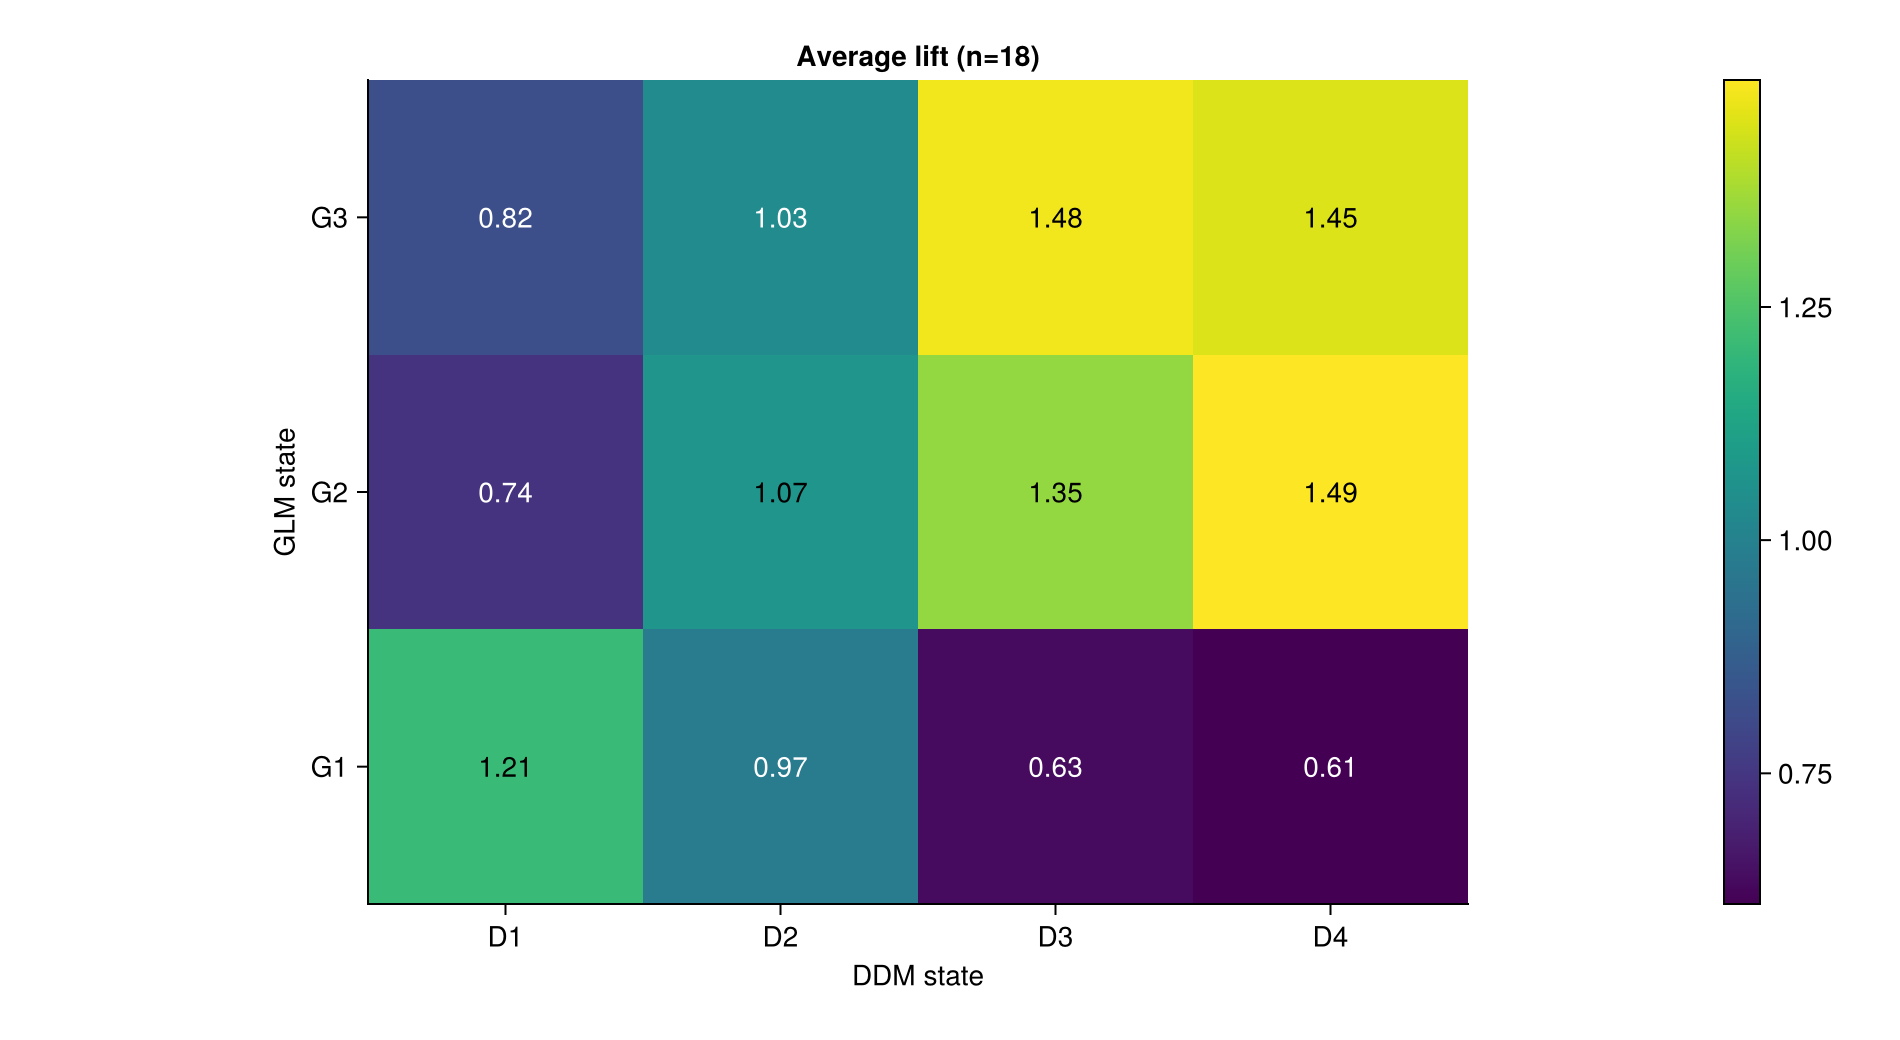

CairoMakie.Screen{EPS}


In [11]:
function pretty_lift_heatmap(avg_lift; title="Average lift", fontsize=14, figsize=(950, 520))
    K1, K2 = size(avg_lift)  # K1=GLM rows, K2=DDM cols

    fig = Figure(size=figsize, figure_padding=(25, 35, 25, 20))  # L,R,B,T
    ax = Axis(fig[1,1];
        title=title,
        xlabel="DDM state",
        ylabel="GLM state",
        aspect=DataAspect(),
        xgridvisible=false,
        ygridvisible=false,
        topspinevisible=false,
        rightspinevisible=false,
    )

    # Plot transposed so x=DDM (1..K2), y=GLM (1..K1)
    hm = CairoMakie.heatmap!(ax, avg_lift')

    # Ticks
    ax.xticks = (1:K2, ["D$(j)" for j in 1:K2])
    ax.yticks = (1:K1, ["G$(i)" for i in 1:K1])

    # Keep cells fully visible / centered
    CairoMakie.xlims!(ax, 0.5, K2 + 0.5)
    CairoMakie.ylims!(ax, 0.5, K1 + 0.5)

    # Colorbar
    Colorbar(fig[1,2], hm, width=18)

    # Contrast-aware annotation colors
    lo, hi = extrema(avg_lift)
    mid = (lo + hi) / 2

    for j in 1:K2          # x (DDM)
        for i in 1:K1      # y (GLM)
            v = avg_lift[i, j]  # original indexing: (GLM, DDM)
            tc = (v < mid) ? :white : :black
            text!(ax, j, i;
                text=@sprintf("%.2f", v),
                align=(:center, :center),
                color=tc,
                fontsize=fontsize
            )
        end
    end

    return fig
end

fig = pretty_lift_heatmap(avg_lift; title="Average lift (n=$n_used)")
display(fig)

save("model_comparison_lift_heatmap.eps", fig)

In [ ]:
# ----------------------------
# NMI from co-occupancy matrix C (K1×K2)
# ----------------------------
function nmi_from_C(C::AbstractMatrix; eps::Float64=1e-12)
    P = float.(C)
    Z = sum(P)
    Z == 0 && return 0.0
    P ./= Z

    p1 = vec(sum(P, dims=2))
    p2 = vec(sum(P, dims=1))

    H1 = -sum(p1 .* log.(p1 .+ eps))
    H2 = -sum(p2 .* log.(p2 .+ eps))

    denom = (p1 .+ eps) * (p2 .+ eps)'   # outer product
    I = sum(P .* log.((P .+ eps) ./ denom))

    return (H1 <= eps || H2 <= eps) ? 0.0 : I / sqrt(H1 * H2)
end

# ----------------------------
# Compute C for a circular shift WITHOUT allocating shifted posteriors
# C_s = sum_t p1[:,t] * p2[:,t+s]' (circular)
# implemented as two GEMMs into a reusable buffer
# ----------------------------
function confusion_shifted!(C::AbstractMatrix, p1::AbstractMatrix, p2::AbstractMatrix, s::Int)
    K1, T = size(p1)
    K2, T2 = size(p2)
    T == T2 || throw(ArgumentError("T mismatch: p1 has T=$T, p2 has T=$T2"))

    s = mod(s, T)
    fill!(C, 0.0)

    if s == 0
        mul!(C, p1, transpose(p2), 1.0, 0.0)
        return C
    end

    # split into non-wrapped + wrapped overlaps
    t1 = 1:(T - s)              # p1 columns
    t2 = (T - s + 1):T

    # C += p1[:,t1] * p2[:,t1+s]'
    mul!(C,
         @view(p1[:, t1]),
         transpose(@view(p2[:, (1+s):T])),
         1.0, 1.0)

    # C += p1[:,t2] * p2[:,1:s]'
    mul!(C,
         @view(p1[:, t2]),
         transpose(@view(p2[:, 1:s])),
         1.0, 1.0)

    return C
end

# ----------------------------
# Per-animal permutation test (fast for :circular)
# ----------------------------
"""
perm_test_alignment_circular(p_glm, p_ddm; nperm=2000, eps=1e-12, rng=MersenneTwister(1))

Returns NamedTuple:
  S_obs, p, z, null_mean, null_std, null_q, S_perm
"""
function perm_test_alignment_circular(p1::AbstractMatrix, p2::AbstractMatrix;
                                      nperm::Int=2000,
                                      eps::Float64=1e-12,
                                      rng::AbstractRNG=Random.default_rng(),
                                      store_perm::Bool=true)

    K1, T = size(p1)
    K2, T2 = size(p2)
    T == T2 || throw(ArgumentError("T mismatch: p1 has T=$T, p2 has T=$T2"))

    C = zeros(Float64, K1, K2)

    # observed at shift 0
    confusion_shifted!(C, p1, p2, 0)
    S_obs = nmi_from_C(C; eps=eps)

    S_perm = store_perm ? Vector{Float64}(undef, nperm) : Float64[]
    μ = 0.0
    m2 = 0.0

    @inbounds for b in 1:nperm
        s = rand(rng, 0:(T-1))
        confusion_shifted!(C, p1, p2, s)
        sb = nmi_from_C(C; eps=eps)

        # running mean/var (Welford)
        δ = sb - μ
        μ += δ / b
        m2 += δ * (sb - μ)

        if store_perm
            S_perm[b] = sb
        end
    end

    σ = nperm > 1 ? sqrt(m2 / (nperm - 1)) : 0.0

    if !store_perm
        error("store_perm=false disables exact p-value. Use store_perm=true.")
    end
    p = (1 + count(>=(S_obs), S_perm)) / (nperm + 1)
    z = (σ == 0.0) ? 0.0 : (S_obs - μ) / σ
    qs = quantile(S_perm, [0.025, 0.5, 0.975])

    return (S_obs=S_obs, p=p, z=z, null_mean=μ, null_std=σ,
            null_q=(q025=qs[1], q50=qs[2], q975=qs[3]),
            S_perm=S_perm)
end

# ----------------------------
# block permutation helper (allocates index vector; slower than circular)
# ----------------------------
function block_permute_cols!(idxbuf::Vector{Int}, T::Int, B::Int, rng::AbstractRNG)
    empty!(idxbuf)
    B = max(1, B)
    nb = cld(T, B)
    perm = randperm(rng, nb)
    for b in perm
        lo = (b-1)*B + 1
        hi = min(b*B, T)
        append!(idxbuf, lo:hi)
    end
    return idxbuf
end

"""
perm_test_alignment_block(p1, p2; nperm=1000, B=50, eps=1e-12, rng=...)

Slower but included. Uses your confusion_matrix() for simplicity.
"""
function perm_test_alignment_block(p1::AbstractMatrix, p2::AbstractMatrix;
                                   nperm::Int=1000,
                                   B::Int=50,
                                   eps::Float64=1e-12,
                                   rng::AbstractRNG=Random.default_rng())

    K1, T = size(p1)
    K2, T2 = size(p2)
    T == T2 || throw(ArgumentError("T mismatch: p1 has T=$T, p2 has T=$T2"))

    # observed
    Cobs = p1 * transpose(p2)
    S_obs = nmi_from_C(Cobs; eps=eps)

    S_perm = Vector{Float64}(undef, nperm)
    idxbuf = Int[]

    @inbounds for b in 1:nperm
        cols = block_permute_cols!(idxbuf, T, B, rng)
        p2b = @view p2[:, cols]  # view, no copy
        C = p1 * transpose(p2b)
        S_perm[b] = nmi_from_C(C; eps=eps)
    end

    p = (1 + count(>=(S_obs), S_perm)) / (nperm + 1)
    μ, σ = mean(S_perm), std(S_perm)
    z = (σ == 0.0) ? 0.0 : (S_obs - μ) / σ
    qs = quantile(S_perm, [0.025, 0.5, 0.975])

    return (S_obs=S_obs, p=p, z=z, null_mean=μ, null_std=σ,
            null_q=(q025=qs[1], q50=qs[2], q975=qs[3]),
            S_perm=S_perm)
end

# ----------------------------
# Cache posteriors once (critical speedup)
# ----------------------------
"""
load_posterior_cache(unique_animals, best_run)

Returns:
  cache::Vector{NamedTuple} with fields:
    animal_id, idx, run_idx, p_glm, p_ddm
"""
function load_posterior_cache(unique_animals, best_run)
    cache = NamedTuple[]
    for (idx, animal_id) in pairs(unique_animals)
        run_idx = best_run[idx]
        p_glm = sort_glmmhmm_posterior(animal_id, run_idx)
        p_ddm_full = sort_ddmhmm_posterior(idx)
        p_ddm = p_ddm_full[:, 2:end]  # your off-by-one fix

        if size(p_glm,2) != size(p_ddm,2)
            @warn "Skipping animal $animal_id: T mismatch glm=$(size(p_glm,2)) ddm=$(size(p_ddm,2))"
            continue
        end

        push!(cache, (animal_id=animal_id, idx=idx, run_idx=run_idx,
                      p_glm=Matrix{Float64}(p_glm),
                      p_ddm=Matrix{Float64}(p_ddm)))
    end
    return cache
end

# ----------------------------
# Group permutation test on weighted mean NMI using stored S_perm arrays
# (same idea as your aggregate_lifts weighting)
# ----------------------------
"""
group_perm_from_peranimal(per_animal; weighted=true)

per_animal entries must have:
  S_obs, S_perm, w

Returns:
  mean_obs, p, z, null_mean, null_std, null_q, n_used
"""
function group_perm_from_peranimal(per_animal::Vector{NamedTuple})
    keep = [r for r in per_animal if haskey(r, :S_perm) && !isempty(r.S_perm)]
    n = length(keep)
    n == 0 && error("No animals with permutation distributions.")

    nperm = length(keep[1].S_perm)
    for r in keep
        length(r.S_perm) == nperm || error("All animals must have same nperm.")
    end

    w = [r.w for r in keep]
    wsum = sum(w)
    mean_obs = sum(w .* [r.S_obs for r in keep]) / wsum

    null_means = Vector{Float64}(undef, nperm)
    @inbounds for b in 1:nperm
        null_means[b] = sum(w .* [r.S_perm[b] for r in keep]) / wsum
    end

    p = (1 + count(>=(mean_obs), null_means)) / (nperm + 1)
    μ, σ = mean(null_means), std(null_means)
    z = (σ == 0.0) ? 0.0 : (mean_obs - μ) / σ
    qs = quantile(null_means, [0.025, 0.5, 0.975])

    return (mean_obs=mean_obs, p=p, z=z,
            null_mean=μ, null_std=σ,
            null_q=(q025=qs[1], q50=qs[2], q975=qs[3]),
            n_used=n)
end

# ----------------------------
# Main: run per-animal + group tests (circular fast; optional block)
# ----------------------------
"""
run_all_alignment_tests(unique_animals, best_run;
                        nulls=[:circular], nperm=2000, B=50, eps=1e-12, weighted=true, rng_seed=1)

Returns Dict{Symbol, NamedTuple} keyed by null symbol. Each entry:
  per_animal  :: Vector{NamedTuple}
  group       :: NamedTuple
"""
function run_all_alignment_tests(unique_animals, best_run;
                                 nulls::Vector{Symbol} = [:circular],
                                 nperm::Int = 2000,
                                 B::Int = 50,
                                 eps::Float64 = 1e-12,
                                 weighted::Bool = true,
                                 rng_seed::Int = 1)

    rng = MersenneTwister(rng_seed)

    cache = load_posterior_cache(unique_animals, best_run)
    length(cache) == 0 && error("No animals cached.")

    out = Dict{Symbol, NamedTuple}()

    for null in nulls
        per_animal = NamedTuple[]
        for r in cache
            p_glm = r.p_glm
            p_ddm = r.p_ddm

            # occupancy mass weight consistent with your lift aggregation
            # (sum(C) where C=p_glm*p_ddm' equals sum over t of 1*1 = T for normalized rows,
            # but keep it as written for consistency; if rows sum to 1, sum(C)=T exactly.)
            C0 = p_glm * transpose(p_ddm)
            w = weighted ? sum(C0) : 1.0

            test = if null == :circular
                perm_test_alignment_circular(p_glm, p_ddm; nperm=nperm, eps=eps, rng=rng)
            elseif null == :block
                perm_test_alignment_block(p_glm, p_ddm; nperm=min(nperm, 1000), B=B, eps=eps, rng=rng)
            else
                throw(ArgumentError("null must be :circular or :block"))
            end

            push!(per_animal, merge((animal_id=r.animal_id, idx=r.idx, run_idx=r.run_idx, null=null, w=w), test))
        end

        group = group_perm_from_peranimal(per_animal)
        out[null] = (per_animal=per_animal, group=group)
    end

    return out
end

run_all_alignment_tests

In [ ]:
res = run_all_alignment_tests(String.(unique_animals), best_run;
                              nulls=[:circular],
                              nperm=100000,
                              eps=1e-12,
                              weighted=true,
                              rng_seed=1)

res[:circular].group          # group-level p, z, null CI
res[:circular].per_animal[1]  # per-animal p, z, null CI


(animal_id = "1029", idx = 1, run_idx = 4, null = :circular, w = 27383.999999999978, S_obs = 0.019667762865594213, p = 0.0027997200279972004, z = 7.048274611298521, null_mean = 0.0025978744800539684, null_std = 0.002421853478605513, null_q = (q025 = 0.00028527334455753464, q50 = 0.001977172054579539, q975 = 0.008612453407474067), S_perm = [0.0007262032746193662, 0.002612021766932761, 0.005502993171465016, 0.003737156661293142, 0.0021671807295072405, 0.0023643267762746, 0.004135700862684946, 0.004565713286765506, 0.0010223778055181948, 0.000422367017232488  …  0.0016995807428705526, 0.0024921995743574263, 0.0025689837438619438, 0.002855693041481587, 0.0015405104840652553, 0.0029690074021406212, 0.00121558296144006, 0.0012090890278318458, 0.00038353803525246783, 0.0016135525518865025])

In [21]:
for i in 1:length(unique_animals)
    println("Animal $(res[:circular].per_animal[i].animal_id): p=$(res[:circular].per_animal[i].p), z=$(res[:circular].per_animal[i].z)")
end

println("Group-level: p=$(res[:circular].group.p), z=$(res[:circular].group.z)")

Animal 1029: p=0.0027997200279972004, z=7.048274611298521
Animal 1052: p=0.00019998000199980003, z=22.689020320212443
Animal 1054: p=9.999000099990002e-5, z=9.7090601352283
Animal 1059: p=9.999000099990002e-5, z=15.55067096695771
Animal 1060: p=9.999000099990002e-5, z=23.66762629679968
Animal 1062: p=9.999000099990002e-5, z=22.842963567225244
Animal 1064: p=9.999000099990002e-5, z=24.178044490003025
Animal 1065: p=9.999000099990002e-5, z=26.91985659623581
Animal 1072: p=0.00019998000199980003, z=13.256556532592487
Animal Denna: p=0.0005999400059994001, z=3.4795217224369184
Animal Dopey: p=0.0004999500049995, z=3.1307284692326194
Animal Draco: p=0.029097090290970903, z=2.4850287283129453
Animal Randy: p=0.0023997600239976003, z=4.978045337837628
Animal Remy: p=0.00019998000199980003, z=5.676593518575336
Animal Rhea: p=0.00019998000199980003, z=7.980905988248232
Animal Robert: p=0.00019998000199980003, z=10.638409841747537
Animal Ron: p=0.007899210078992101, z=3.5987192794471916
Animal R

In [65]:
"Benjamini–Hochberg FDR correction. Returns q-values in original order."
function bh_fdr(ps::AbstractVector{<:Real})
    p = collect(float.(ps))
    n = length(p)
    ord = sortperm(p)
    q_sorted = similar(p)

    # BH: q_i = min_{j>=i} (n/j) * p_(j)
    prev = Inf
    for (rank, idx) in Iterators.reverse(enumerate(ord))
        # rank here is position in ord? enumerate gives (pos, idx); we want pos.
        pos = rank
        val = (n / pos) * p[idx]
        prev = min(prev, val)
        q_sorted[pos] = prev
    end

    # map back to original order
    q = similar(p)
    for (pos, idx) in enumerate(ord)
        q[idx] = min(q_sorted[pos], 1.0)
    end
    return q
end

"Extract vectors from per_animal NamedTuples and sort by z (or p)."
function extract_per_animal(per_animal; sortby::Symbol=:z)
    animals = [string(r.animal_id) for r in per_animal]
    ps      = [r.p for r in per_animal]
    zs      = [r.z for r in per_animal]

    qvals = bh_fdr(ps)

    ord = if sortby == :z
        sortperm(zs)
    elseif sortby == :p
        sortperm(ps)
    else
        1:length(per_animal)
    end

    return (animals=animals[ord],
            p=ps[ord],
            z=zs[ord],
            q=qvals[ord],
            ord=ord)
end

"Compute group null means (weighted) from per_animal S_perm arrays."
function group_null_means(per_animal; weighted::Bool=true)
    keep = [r for r in per_animal if haskey(r, :S_perm) && !isempty(r.S_perm)]
    n = length(keep)
    n == 0 && error("No animals with S_perm stored.")
    nperm = length(keep[1].S_perm)
    for r in keep
        length(r.S_perm) == nperm || error("All animals must share same nperm.")
    end

    # weights: use r.w if present, else equal weights
    w = if weighted && haskey(keep[1], :w)
        [r.w for r in keep]
    else
        ones(Float64, n)
    end
    wsum = sum(w)

    mean_obs = sum(w .* [r.S_obs for r in keep]) / wsum

    null_means = Vector{Float64}(undef, nperm)
    @inbounds for b in 1:nperm
        null_means[b] = sum(w .* [r.S_perm[b] for r in keep]) / wsum
    end

    p = (1 + count(>=(mean_obs), null_means)) / (nperm + 1)
    z = (std(null_means) == 0.0) ? 0.0 : (mean_obs - mean(null_means)) / std(null_means)

    return (mean_obs=mean_obs, null_means=null_means, p=p, z=z)
end

function fig_zscores(per_animal; outfile::String="zscores_by_animal.png")
    d = extract_per_animal(per_animal; sortby=:z)
    n = length(d.z)
    x = 1:n

    fig = Figure(size=(650, 520))
    ax = Axis(fig[1,1],
              title="GLM-HMM vs DDM-HMM alignment (circular-shift null): per-animal z-scores",
              xlabel="Animals (sorted by z)",
              ylabel="z-score")

    CairoMakie.scatter!(ax, x, d.z, markersize=10)

    # significance reference lines (two-sided z≈1.96; one-sided z≈1.645)
    CairoMakie.hlines!(ax, [1.96,], linestyle=:dash)

    # label animals on x-axis
    ax.xticks = (x, d.animals)
    ax.xticklabelrotation = pi/3
    ax.xticklabelalign = (:right, :center)

    save(outfile, fig, px_per_unit=2)
    return fig
end

function fig_logp(per_animal; outfile::String="logp_by_animal.png")
    d = extract_per_animal(per_animal; sortby=:p)
    n = length(d.p)
    x = 1:n

    # handle p=0 floor; also show permutation resolution p_min ~ 1/(nperm+1)
    # try to infer nperm from first animal:
    nperm = haskey(per_animal[1], :S_perm) ? length(per_animal[1].S_perm) : nothing
    pmin = nperm === nothing ? minimum(d.p) : 1/(nperm+1)

    y = -log10.(max.(d.p, pmin))  # clamp to floor for plotting

    fig = Figure(size=(1100, 520))
    ax = Axis(fig[1,1],
              title="Permutation p-values by animal (sorted by p)",
              xlabel="Animals (sorted by p)",
              ylabel="-log10(p)")

    CairoMakie.barplot!(ax, x, y)

    # mark alpha=0.05
    hlines!(ax, [-log10(0.05)], linestyle=:dash)

    ax.xticks = (x, d.animals)
    ax.xticklabelrotation = pi/3
    ax.xticklabelalign = (:right, :center)

    # annotate floor if we can
    if nperm !== nothing
        CairoMakie.text!(ax, n, y[end] + 0.3,
              text="floor p≈$(round(pmin, sigdigits=2))",
              align=(:right, :bottom), fontsize=11)
    end

    save(outfile, fig, px_per_unit=2)
    return fig
end

function fig_group_null(per_animal; outfile::String="group_null_hist.png", weighted::Bool=true)
    g = group_null_means(per_animal; weighted=weighted)
    nulls = g.null_means
    obs = g.mean_obs

    fig = Figure(size=(900, 520))
    ax = Axis(fig[1,1],
              title="Group-level alignment: mean NMI vs circular-shift null",
              xlabel="Mean NMI (across animals)",
              ylabel="Count")

    h = CairoMakie.hist!(ax, nulls, bins=50)   # returns a plot object
    CairoMakie.vlines!(ax, [obs], linewidth=3)

    # Place annotation robustly using data ranges
    ymax = maximum(h[1][] )  # counts (works reliably)
    xmin, xmax = extrema(nulls)

    txt = "obs=$(round(obs, sigdigits=4))\n" *
          "perm p=$(g.p < 1e-4 ? "<1e-4" : string(round(g.p, sigdigits=3)))\n" *
          "z=$(round(g.z, sigdigits=3))"

    # put text near top-left of the histogram
    text!(ax,
          xmin + 0.02*(xmax - xmin),
          0.95*ymax,
          text=txt, align=(:left, :top), fontsize=12)

    save(outfile, fig, px_per_unit=2)
    return fig
end

function fig_example_null(per_animal, animal_name::AbstractString; outfile::String="example_null.png")
    idx = findfirst(r -> string(r.animal_id) == animal_name, per_animal)
    idx === nothing && error("Animal '$animal_name' not found.")

    r = per_animal[idx]
    haskey(r, :S_perm) || error("No S_perm stored for this animal.")
    nulls = r.S_perm
    obs = r.S_obs

    fig = Figure(size=(900, 520))
    ax = Axis(fig[1,1],
              title="Example animal: $animal_name (NMI vs circular-shift null)",
              xlabel="NMI",
              ylabel="Count")

    h = CairoMakie.hist!(ax, nulls, bins=50)
    CairoMakie.vlines!(ax, [obs], linewidth=3)

    ymax = maximum(h[1][])
    xmin, xmax = extrema(nulls)

    txt = "obs=$(round(obs, sigdigits=4))\n" *
          "perm p=$(r.p < 1e-4 ? "<1e-4" : string(round(r.p, sigdigits=3)))\n" *
          "z=$(round(r.z, sigdigits=3))"

    text!(ax,
          xmin + 0.02*(xmax - xmin),
          0.95*ymax,
          text=txt, align=(:left, :top), fontsize=12)

    save(outfile, fig, px_per_unit=2)
    return fig
end


fig_example_null (generic function with 1 method)

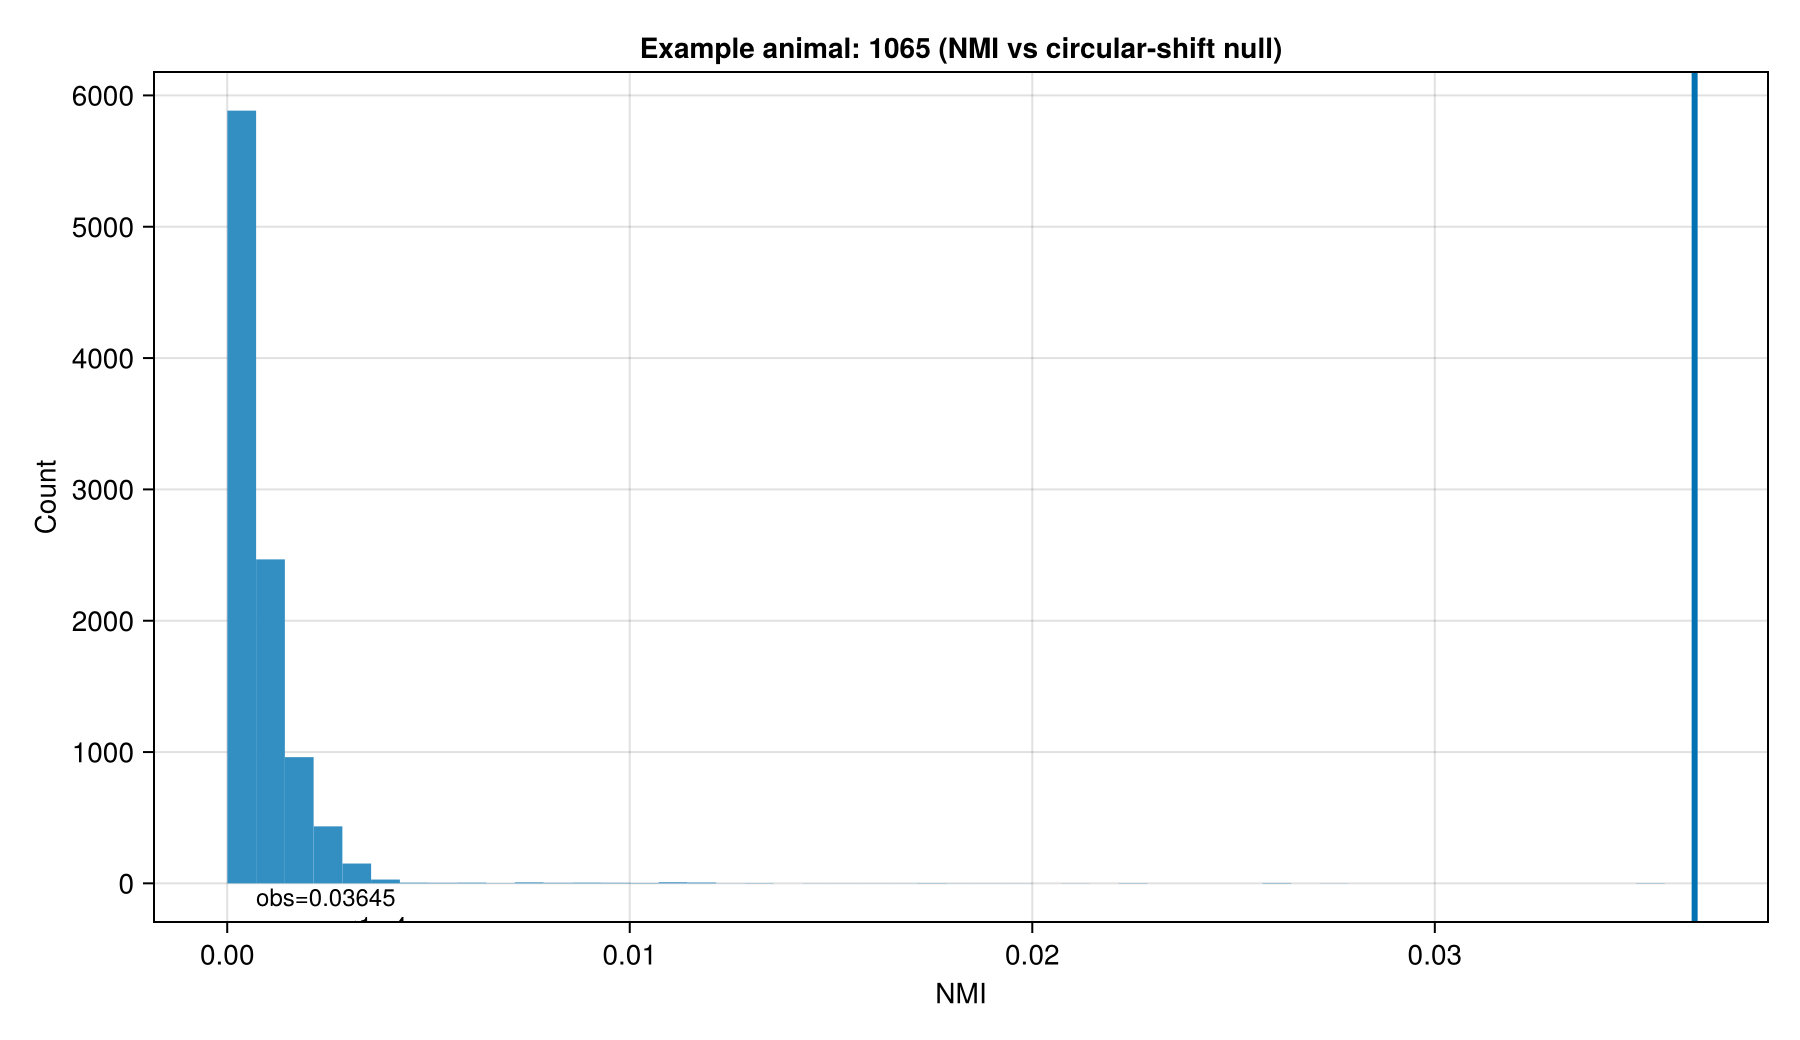

In [66]:
per = res[:circular].per_animal

fig_zscores(per; outfile="zscores_by_animal.eps")
fig_logp(per; outfile="logp_by_animal.eps")
fig_group_null(per; outfile="group_null_hist.eps", weighted=true)

# Optional: show Draco and a high-z example
fig_example_null(per, "Draco"; outfile="null_Draco.eps")
fig_example_null(per, "1065"; outfile="null_1065.eps")   # change to one of your IDs

In [39]:
function mi_and_entropies_from_C(C; eps=1e-12)
    P = float.(C)
    Z = sum(P); Z == 0 && return (I=0.0, H1=0.0, H2=0.0)
    P ./= Z
    p1 = vec(sum(P, dims=2))
    p2 = vec(sum(P, dims=1))
    H1 = -sum(p1 .* log.(p1 .+ eps))
    H2 = -sum(p2 .* log.(p2 .+ eps))
    denom = (p1 .+ eps) * (p2 .+ eps)'
    I = sum(P .* log.((P .+ eps) ./ denom))
    return (I=I, H1=H1, H2=H2)
end

# fraction of uncertainty in model2 state explained by model1
function frac_explained_from_C(C; eps=1e-12)
    m = mi_and_entropies_from_C(C; eps=eps)
    return (m.H2 <= eps) ? 0.0 : m.I / m.H2
end

function frac_explained_reverse_from_C(C; eps=1e-12)
    m = mi_and_entropies_from_C(C; eps=eps)
    return (m.H1 <= eps) ? 0.0 : m.I / m.H1
end

function aggregate_frac_explained(unique_animals, best_run; eps=1e-12, weighted=true)
    vals12 = Float64[]   # I/H(DDM): GLM -> DDM
    vals21 = Float64[]   # I/H(GLM): DDM -> GLM
    wts    = Float64[]

    for (idx, animal_id) in pairs(unique_animals)
        run_idx = best_run[idx]
        p_glm = sort_glmmhmm_posterior(animal_id, run_idx)
        p_ddm = sort_ddmhmm_posterior(idx)[:, 2:end]

        size(p_glm,2) == size(p_ddm,2) || begin
            @warn "Skipping animal $animal_id: T mismatch"
            continue
        end

        C = confusion_matrix(p_glm, p_ddm; mode=:soft, normalize=nothing)
        push!(vals12, frac_explained_from_C(C; eps=eps))
        push!(vals21, frac_explained_reverse_from_C(C; eps=eps))
        push!(wts, weighted ? sum(C) : 1.0)
    end

    length(vals12) == 0 && error("No animals used")

    wsum = sum(wts)
    mean12 = sum(wts .* vals12) / wsum
    mean21 = sum(wts .* vals21) / wsum

    return (mean_glm_to_ddm=mean12, mean_ddm_to_glm=mean21,
            per_animal_glm_to_ddm=vals12, per_animal_ddm_to_glm=vals21,
            weights=wts, n_used=length(vals12))
end


aggregate_frac_explained (generic function with 1 method)

In [40]:
r = aggregate_frac_explained(String.(unique_animals), best_run; weighted=true)
println("GLM→DDM explained entropy: $(round(100*r.mean_glm_to_ddm, digits=2))%")
println("DDM→GLM explained entropy: $(round(100*r.mean_ddm_to_glm, digits=2))%")


GLM→DDM explained entropy: 4.56%
DDM→GLM explained entropy: 5.58%


In [41]:
function fit_state_bernoulli_rates(post::AbstractMatrix, y::AbstractVector{<:Real}; eps=1e-12)
    K, T = size(post); @assert length(y) == T
    γ = float.(post); yy = float.(y)
    denom = vec(sum(γ, dims=2)) .+ eps
    π = (γ * yy) ./ denom                      # K-vector
    π = clamp.(π, eps, 1 - eps)
    return π
end

function predict_from_state_rates(post::AbstractMatrix, π::AbstractVector)
    # p_t = Σ_k γ_k(t) π_k
    return vec(transpose(π) * post)
end

function logloss(y, p; eps=1e-12)
    pp = clamp.(float.(p), eps, 1-eps)
    yy = float.(y)
    return -mean(yy .* log.(pp) .+ (1 .- yy) .* log.(1 .- pp))
end

function brier(y, p)
    yy = float.(y); pp = float.(p)
    return mean((pp .- yy).^2)
end

brier (generic function with 1 method)

In [48]:
all_results, seq_ends, results_by_date = data_for_ddmhmm(1)
choices = [r.choice for r in all_results]
# replace -1s with 0s
choices = replace(choices, -1 => 0)

p_glm = sort_glmmhmm_posterior(String(unique_animals[1]), best_run[1])
p_ddm = sort_ddmhmm_posterior(1)[:, 2:end] 

fit_state_bernoulli_rates(p_glm, choices[2:end])
fit_state_bernoulli_rates(p_ddm, choices[2:end])

4-element Vector{Float64}:
 0.3639952933846412
 0.2992531552723437
 0.2753362708185819
 0.3045617808348931

In [50]:
predict_from_state_rates(p_glm, fit_state_bernoulli_rates(p_glm, choices[2:end]))
logloss(choices[2:end], predict_from_state_rates(p_glm, fit_state_bernoulli_rates(p_glm, choices[2:end])))

0.6021886948954955

In [51]:
predict_from_state_rates(p_ddm, fit_state_bernoulli_rates(p_ddm, choices[2:end]))
logloss(choices[2:end], predict_from_state_rates(p_ddm, fit_state_bernoulli_rates(p_ddm, choices[2:end])))

0.6240846499956576

In [57]:
# y ∈ {0,1}, post is K×T
function fit_state_bernoulli_rates(post::AbstractMatrix, y::AbstractVector{<:Real}; eps=1e-12)
    K, T = size(post); @assert length(y) == T
    γ = float.(post); yy = float.(y)
    denom = vec(sum(γ, dims=2)) .+ eps
    π = (γ * yy) ./ denom
    return clamp.(π, eps, 1 - eps)
end

predict_from_state_rates(post::AbstractMatrix, π::AbstractVector) = vec(transpose(π) * post)

function logloss(y::AbstractVector{<:Real}, p::AbstractVector{<:Real}; eps=1e-12)
    @assert length(y) == length(p)
    pp = clamp.(float.(p), eps, 1 - eps)
    yy = float.(y)
    return -mean(yy .* log.(pp) .+ (1 .- yy) .* log.(1 .- pp))
end

function brier(y::AbstractVector{<:Real}, p::AbstractVector{<:Real})
    @assert length(y) == length(p)
    yy = float.(y); pp = float.(p)
    return mean((pp .- yy).^2)
end

# contiguous blocked folds
function blocked_folds(T::Int, nb::Int)
    edges = round.(Int, range(1, T+1; length=nb+1))
    return [edges[i]:(edges[i+1]-1) for i in 1:nb]
end

"""
posterior_choice_scores(post, y; nb=5)
Returns in-sample scores + blocked pseudo-CV scores.
"""
function posterior_choice_scores(post::AbstractMatrix, y::AbstractVector{<:Real}; nb::Int=5, eps=1e-12)
    K, T = size(post); @assert length(y) == T

    # in-sample
    π_full = fit_state_bernoulli_rates(post, y; eps=eps)
    p_full = predict_from_state_rates(post, π_full)
    ll_in  = logloss(y, p_full; eps=eps)
    br_in  = brier(y, p_full)

    # blocked pseudo-CV: fit π on train blocks, score on held-out block
    folds = blocked_folds(T, nb)
    ll_cv = Float64[]
    br_cv = Float64[]
    for test in folds
        train = collect(1:T)
        deleteat!(train, collect(test))  # remove test indices
        π = fit_state_bernoulli_rates(@view(post[:, train]), @view(y[train]); eps=eps)
        p̂ = predict_from_state_rates(@view(post[:, test]), π)
        push!(ll_cv, logloss(@view(y[test]), p̂; eps=eps))
        push!(br_cv, brier(@view(y[test]), p̂))
    end

    return (ll_in=ll_in, br_in=br_in,
            ll_cv=mean(ll_cv), br_cv=mean(br_cv),
            fold_ll=ll_cv, fold_br=br_cv)
end

function get_choices_aligned(idx)
    all_results, _, _ = data_for_ddmhmm(idx)
    y = [r.choice == r.s for r in all_results]
    return y[2:end]                     
end

function compare_models_posterior_choice(unique_animals, best_run; nb::Int=5, eps=1e-12)
    rows = NamedTuple[]
    for (idx, animal_id) in pairs(unique_animals)
        run_idx = best_run[idx]

        y = get_choices_aligned(idx)

        p_glm = sort_glmmhmm_posterior(String(animal_id), run_idx)   # K×T
        p_ddm = sort_ddmhmm_posterior(idx)[:, 2:end]                 # K×T

        T = length(y)
        size(p_glm,2) == T || (@warn "Skip $animal_id: glm T=$(size(p_glm,2)) y T=$T"; continue)
        size(p_ddm,2) == T || (@warn "Skip $animal_id: ddm T=$(size(p_ddm,2)) y T=$T"; continue)

        s_glm = posterior_choice_scores(p_glm, y; nb=nb, eps=eps)
        s_ddm = posterior_choice_scores(p_ddm, y; nb=nb, eps=eps)

        push!(rows, (
            animal = string(animal_id),
            T = T,
            glm_ll_in = s_glm.ll_in,
            ddm_ll_in = s_ddm.ll_in,
            glm_ll_cv = s_glm.ll_cv,
            ddm_ll_cv = s_ddm.ll_cv,
            glm_br_in = s_glm.br_in,
            ddm_br_in = s_ddm.br_in,
            glm_br_cv = s_glm.br_cv,
            ddm_br_cv = s_ddm.br_cv
        ))
    end
    return rows
end


compare_models_posterior_choice (generic function with 1 method)

In [84]:
function plot_choice_comparison(rows; use_cv::Bool=true, outfile_prefix::String="choice_compare")
    animals = [r.animal for r in rows]

    glm = use_cv ? [r.glm_ll_cv for r in rows] : [r.glm_ll_in for r in rows]
    ddm = use_cv ? [r.ddm_ll_cv for r in rows] : [r.ddm_ll_in for r in rows]

    # Figure 1: scatter GLM vs DDM
    lo = min(minimum(glm), minimum(ddm))
    hi = max(maximum(glm), maximum(ddm))

    p1 = Plots.scatter(glm, ddm;
        fontfamily="helvetica",
        xlabel="GLM-HMM log loss",
        ylabel="DDM-HMM log loss",
        title = use_cv ? "Posterior-only blocked score (lower is better)" :
                         "Posterior-only in-sample score (lower is better)",
        legend=false,
        markersize=6,
        framestyle=:box,
        size=(650, 650),
    )

    # diagonal y=x
    Plots.plot!(p1, [lo, hi], [lo, hi];
        linestyle=:dash,
        linewidth=2,
        label=false,
    )

    savefig(p1, "$(outfile_prefix)_scatter.svg")


    # Figure 2: paired differences Δ = ddm - glm
    Δ = ddm .- glm
    ord = sortperm(Δ)
    Δs = Δ[ord]
    labs = animals[ord]
    x = 1:length(Δs)

    μ = mean(Δ)
    sem = std(Δ) / sqrt(length(Δ))

    p2 = Plots.scatter(x, Δs;
        fontfamily="helvetica",
        xlabel="Animals (sorted)",
        ylabel="Δ log loss (DDM − GLM)",
        title = use_cv ? "Δ log loss (DDM − GLM), blocked posterior-only" :
                         "Δ log loss (DDM − GLM), in-sample posterior-only",
        legend=false,
        markersize=5,
        framestyle=:box,
        size=(700, 650),
        xticks=(x, labs),
    )

    # horizontal zero line
    Plots.hline!(p2, [0.0]; linestyle=:dash, linewidth=2, label=false)

    # annotation near top-left of plot
    ytop = maximum(Δs)
    ybot = minimum(Δs)
    y_annot = ytop - 0.05*(ytop - ybot)
    Plots.annotate!(p2, 1, y_annot,
        Plots.text("mean Δ = $(round(μ, sigdigits=3)) ± $(round(sem, sigdigits=2)) (SEM)", 10, :left)
    )

    savefig(p2, "$(outfile_prefix)_delta.svg")

    return p1, p2
end




plot_choice_comparison (generic function with 1 method)

In [85]:
rows = compare_models_posterior_choice(unique_animals, best_run; nb=5)

# pseudo-CV comparison
plot_choice_comparison(rows; use_cv=true, outfile_prefix="choice_cv")

# in-sample comparison (descriptive)
plot_choice_comparison(rows; use_cv=false, outfile_prefix="choice_insample")

(Plot{Plots.GRBackend() n=2}, Plot{Plots.GRBackend() n=2})